# Pancreatic cancer Boolean network model

Replication of Vundavilli et al. 2020 https://ieeexplore.ieee.org/document/8476214

In [1]:
import random
import sys

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from KGBN import booleanNetwork as bn
from KGBN import BMatrix  

## Loading the model

In [2]:
network_desc = """EGF = EGF
HBEGF = HBEGF
IGF = IGF
NRG1 = NRG1
PTEN = PTEN
LKB1 = LKB1
EGFR = EGF
EFGR = HBEGF | EGF
IGFR1A_B = IGF
ERBB2 = NRG1
JAK5 = EGFR
STAT3 = JAK5
IRS1 = IGFR1A_B
GRB2 = (ERBB2 | IGFR1A_B) | (EFGR | EGFR)
RAS = GRB2
MEKK1 = RAS
RAF = RAS
MKK4 = MEKK1
MEK1 = RAF
PIK3CA = (ERBB2 | IRS1) | (RAS | STAT3)
JNK1 = MKK4
ERK1_2 = MEK1
PIP3 = ! PTEN | PIK3CA
PDPK1 = PIP3
AKT1 = PIP3
AMPK = LKB1
GSK3 = ! AKT1
TSC1_2 = AMPK | ( ! AKT1)
RHEB = ! TSC1_2
mTOR = RHEB
RPS6KB1 = mTOR | (PDPK1 | ERK1_2)
BAD = ! (AKT1 | RPS6KB1)
CCND1 = ! GSK3
BCL2 = ( ! BAD & STAT3)
SRFELK1 = RPS6KB1 & ERK1_2
FOS-JUN = RPS6KB1 & JNK1
SRFELK4 = RPS6KB1 & ERK1_2
SP1 = ERK1_2"""

In [3]:
network = BMatrix.load_network_from_string(network_desc)

No initial state provided, using a random initial state
Network loaded successfully. There are 38 genes in the network.


## Replicating paper

Input = [PTEN, LKB1, EGF, HBEGF, IGF, NRG1]

Output = [CCND1, BCL2, SRF-ELK1, FOS-JUN, SRF-ELK4, SP1]

If outputs are all 0, then this is a lack of cell proliferation and a non-suppression of apoptosis. A network without faults will produce a 0 output. However, a network with faults will produce a nonzero output vector, leading to a proliferative state.

Drug = [Cryptotanshinone, LY294002, Temsirolimus, Lapatinib, HO-3867]

Faults for every node/gene - they can be either stuck at 0 or stuck at 1.

"Size Difference" metric = (differences/total entries)^2 (just the square of the hamming distance?)

For each fault, and each drug, we calculate the output.

I'm not sure what the input is used for these runs?

Original code for paper: https://github.com/hashwanthvv/boolean/blob/master/pancreatic_one_fault.m

In [4]:
input_genes = ['PTEN', 'LKB1', 'EGF', 'HBEGF', 'IGF', 'NRG1']
output_genes = ['CCND1', 'BCL2', 'SRFELK1', 'FOS-JUN', 'SRFELK4', 'SP1']
# stuck at 0 faults
fault_genes_0 = set(['TSC1/2', 'BAD', 'GSK3'])
# stuck at 1 faults
fault_genes = [g for g in network.nodeDict.keys() if g not in input_genes and g not in output_genes]


In [5]:
# TODO: add faults/mutations?
# for all inputs, 
# 1. set inputs
network.setInitialValue('PTEN', 1)
network.setInitialValue('LKB1', 1)
network.setInitialValue('EGF', 0)
network.setInitialValue('HBEGF', 0)
network.setInitialValue('IGF', 0)
network.setInitialValue('NRG1', 0)


In [6]:
results = network.update(10)

In [7]:
output_baseline_results = [results[-1, network.nodeDict[k]] for k in output_genes]

In [8]:
output_baseline_results

[0, 0, 0, 0, 0, 0]

The baseline results should be all 0s.

### No Drug

In [9]:
all_results = []
for i, g1 in enumerate(fault_genes):
    print(i, g1)
    for j, g2 in enumerate(fault_genes[i+1:]):
        for g in fault_genes[j+1:]:
            network.undoKnockouts()
            network.setInitialValue('PTEN', 1)
            network.setInitialValue('LKB1', 1)
            network.setInitialValue('EGF', 0)
            network.setInitialValue('HBEGF', 0)
            network.setInitialValue('IGF', 0)
            network.setInitialValue('NRG1', 0)
            if g in fault_genes_0:
                network.knockout(g, 0)
            else:
                network.knockout(g, 1)
            if g1 in fault_genes_0:
                network.knockout(g1, 0)
            else:
                network.knockout(g1, 1)
            if g2 in fault_genes_0:
                network.knockout(g2, 0)
            else:
                network.knockout(g2, 1)
            results = network.update(27)
            output = [results[-1, network.nodeDict[k]] for k in output_genes]
            all_results.append(output)
            network.undoKnockouts()

0 EGFR
1 EFGR
2 IGFR1A_B
3 ERBB2
4 JAK5
5 STAT3
6 IRS1
7 GRB2
8 RAS
9 MEKK1
10 RAF
11 MKK4
12 MEK1
13 PIK3CA
14 JNK1
15 ERK1_2
16 PIP3
17 PDPK1
18 AKT1
19 AMPK
20 GSK3
21 TSC1_2
22 RHEB
23 mTOR
24 RPS6KB1
25 BAD


In [10]:
all_results = np.array(all_results)

In [11]:
# calculate size difference without treatment
size_difference = all_results.sum(1)**2/6**2

(array([1129.,  646.,  425.,    0.,  662.,    0., 1988.,    0.,    0.,
         675.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

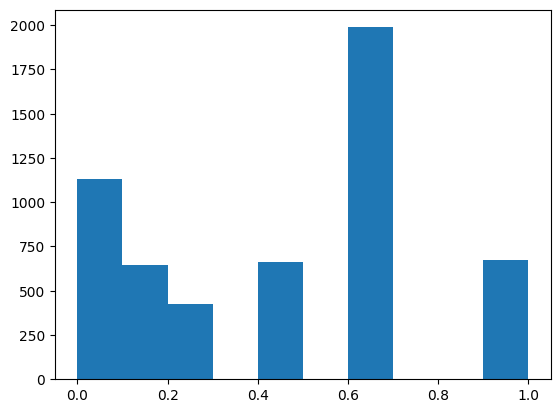

In [12]:
import matplotlib.pyplot as plt
plt.hist(size_difference)

### Single drug effects

In [34]:
drugs = ['Untreated', 'HO-3867', 'Lapatinib', 'Temsirolimus', 'LY294002', 'Cryptotanshinone']
drug_knockouts = {'Cryptotanshinone': ['STAT3', 'ERK1_2'],
                  'LY294002': ['PIK3CA'],
                  'Temsirolimus': ['mTOR'], 
                  'Lapatinib': ['EGFR', 'EFGR', 'ERBB2'],
                  'HO-3867': ['STAT3'],
                  'Untreated': []
                 }

In [14]:
# single-drug combinations
# faults for each drug
all_results_single_drug = {d: [] for d in drugs}
all_results_double_drug = {}
for i, g1 in enumerate(fault_genes):
    print(i, g1)
    for j, g2 in enumerate(fault_genes[i+1:]):
        for g in fault_genes[j+1:]:
            for d in drugs:
                network.undoKnockouts()
                network.setInitialValue('PTEN', 1)
                network.setInitialValue('LKB1', 1)
                network.setInitialValue('EGF', 0)
                network.setInitialValue('HBEGF', 0)
                network.setInitialValue('IGF', 0)
                network.setInitialValue('NRG1', 0)
                if g in fault_genes_0:
                    network.knockout(g, 0)
                else:
                    network.knockout(g, 1)
                if g1 in fault_genes_0:
                    network.knockout(g1, 0)
                else:
                    network.knockout(g1, 1)
                if g2 in fault_genes_0:
                    network.knockout(g2, 0)
                else:
                    network.knockout(g2, 1)
                # set drug effects
                for ko in drug_knockouts[d]:
                    network.knockout(ko, 0)
                results = network.update(27)
                output = [results[-1, network.nodeDict[k]] for k in output_genes]
                all_results_single_drug[d].append(output)
                network.undoKnockouts()

0 EGFR
1 EFGR
2 IGFR1A_B
3 ERBB2
4 JAK5
5 STAT3
6 IRS1
7 GRB2
8 RAS
9 MEKK1
10 RAF
11 MKK4
12 MEK1
13 PIK3CA
14 JNK1
15 ERK1_2
16 PIP3
17 PDPK1
18 AKT1
19 AMPK
20 GSK3
21 TSC1_2
22 RHEB
23 mTOR
24 RPS6KB1
25 BAD


In [15]:
size_differences_single_drug = {}
size_differences_single_drug['Untreated'] = size_difference
for k, v in all_results_single_drug.items():
    v = np.array(v)
    size_differences_single_drug[k] = v.sum(1)**2/6**2


In [16]:
size_differences_single_drug = pd.DataFrame(size_differences_single_drug)

Text(0, 0.5, 'Size difference (Hamming distance^2)')

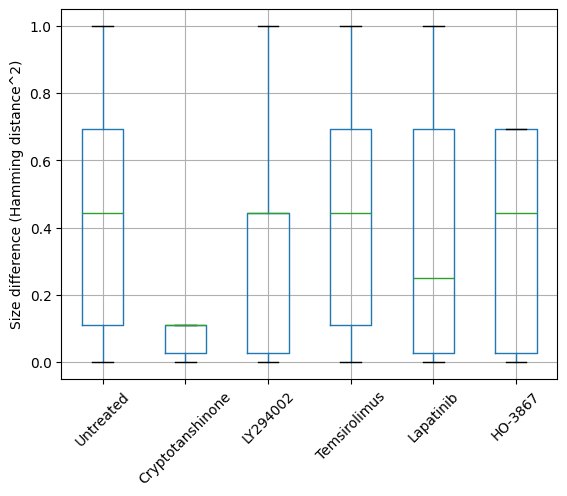

In [17]:
ax = size_differences_single_drug.boxplot()
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Size difference (Hamming distance^2)')


This looks pretty much the same as Fig. 5 in the paper (minus multi-drug combinations). Although, this is triple mutants only. No single and double mutants here.

### Replicating Fig. 5

In [18]:
import itertools
double_drugs = list(itertools.combinations([d for d in drugs if d != 'Untreated'], 2))

In [19]:
list(double_drugs)

[('Cryptotanshinone', 'LY294002'),
 ('Cryptotanshinone', 'Temsirolimus'),
 ('Cryptotanshinone', 'Lapatinib'),
 ('Cryptotanshinone', 'HO-3867'),
 ('LY294002', 'Temsirolimus'),
 ('LY294002', 'Lapatinib'),
 ('LY294002', 'HO-3867'),
 ('Temsirolimus', 'Lapatinib'),
 ('Temsirolimus', 'HO-3867'),
 ('Lapatinib', 'HO-3867')]

In [20]:
# single-fault mutations
single_fault_results_single_drug = {d: [] for d in drugs}
single_fault_results_double_drug = {d: [] for d in double_drugs}
for i, g in enumerate(fault_genes):
    print(i, g)
    for d in drugs:
        network.undoKnockouts()
        network.setInitialValue('PTEN', 1)
        network.setInitialValue('LKB1', 1)
        network.setInitialValue('EGF', 0)
        network.setInitialValue('HBEGF', 0)
        network.setInitialValue('IGF', 0)
        network.setInitialValue('NRG1', 0)
        if g in fault_genes_0:
            network.knockout(g, 0)
        else:
            network.knockout(g, 1)
        # set drug effects
        for ko in drug_knockouts[d]:
            network.knockout(ko, 0)
        results = network.update(27)
        output = [results[-1, network.nodeDict[k]] for k in output_genes]
        single_fault_results_single_drug[d].append(output)
        network.undoKnockouts()
    for d1, d2 in double_drugs:
        network.undoKnockouts()
        network.setInitialValue('PTEN', 1)
        network.setInitialValue('LKB1', 1)
        network.setInitialValue('EGF', 0)
        network.setInitialValue('HBEGF', 0)
        network.setInitialValue('IGF', 0)
        network.setInitialValue('NRG1', 0)
        if g in fault_genes_0:
            network.knockout(g, 0)
        else:
            network.knockout(g, 1)
        # set drug effects
        for ko in drug_knockouts[d1] + drug_knockouts[d2]:
            network.knockout(ko, 0)
        results = network.update(27)
        output = [results[-1, network.nodeDict[k]] for k in output_genes]
        single_fault_results_double_drug[(d1, d2)].append(output)
        network.undoKnockouts()

0 EGFR
1 EFGR
2 IGFR1A_B
3 ERBB2
4 JAK5
5 STAT3
6 IRS1
7 GRB2
8 RAS
9 MEKK1
10 RAF
11 MKK4
12 MEK1
13 PIK3CA
14 JNK1
15 ERK1_2
16 PIP3
17 PDPK1
18 AKT1
19 AMPK
20 GSK3
21 TSC1_2
22 RHEB
23 mTOR
24 RPS6KB1
25 BAD


In [21]:
# double-fault mutations
double_mutants = list(itertools.combinations(fault_genes, 2))
# single-fault mutations
double_fault_results_single_drug = {d: [] for d in drugs}
double_fault_results_double_drug = {d: [] for d in double_drugs}
for genes in double_mutants:
    for d in drugs:
        network.undoKnockouts()
        network.setInitialValue('PTEN', 1)
        network.setInitialValue('LKB1', 1)
        network.setInitialValue('EGF', 0)
        network.setInitialValue('HBEGF', 0)
        network.setInitialValue('IGF', 0)
        network.setInitialValue('NRG1', 0)
        for g in genes:
            if g in fault_genes_0:
                network.knockout(g, 0)
            else:
                network.knockout(g, 1)
        # set drug effects
        for ko in drug_knockouts[d]:
            network.knockout(ko, 0)
        results = network.update(27)
        output = [results[-1, network.nodeDict[k]] for k in output_genes]
        double_fault_results_single_drug[d].append(output)
        network.undoKnockouts()
    for d1, d2 in double_drugs:
        network.undoKnockouts()
        network.setInitialValue('PTEN', 1)
        network.setInitialValue('LKB1', 1)
        network.setInitialValue('EGF', 0)
        network.setInitialValue('HBEGF', 0)
        network.setInitialValue('IGF', 0)
        network.setInitialValue('NRG1', 0)
        for g in genes:
            if g in fault_genes_0:
                network.knockout(g, 0)
            else:
                network.knockout(g, 1)
        # set drug effects
        for ko in drug_knockouts[d1] + drug_knockouts[d2]:
            network.knockout(ko, 0)
        results = network.update(27)
        output = [results[-1, network.nodeDict[k]] for k in output_genes]
        double_fault_results_double_drug[(d1, d2)].append(output)
        network.undoKnockouts()

In [22]:
# triple-fault mutations
# double-fault mutations
triple_mutants = list(itertools.combinations(fault_genes, 3))
# single-fault mutations
triple_fault_results_single_drug = {d: [] for d in drugs}
triple_fault_results_double_drug = {d: [] for d in double_drugs}
for genes in triple_mutants:
    for d in drugs:
        network.undoKnockouts()
        network.setInitialValue('PTEN', 1)
        network.setInitialValue('LKB1', 1)
        network.setInitialValue('EGF', 0)
        network.setInitialValue('HBEGF', 0)
        network.setInitialValue('IGF', 0)
        network.setInitialValue('NRG1', 0)
        for g in genes:
            if g in fault_genes_0:
                network.knockout(g, 0)
            else:
                network.knockout(g, 1)
        # set drug effects
        for ko in drug_knockouts[d]:
            network.knockout(ko, 0)
        results = network.update(27)
        output = [results[-1, network.nodeDict[k]] for k in output_genes]
        triple_fault_results_single_drug[d].append(output)
        network.undoKnockouts()
    for d1, d2 in double_drugs:
        network.undoKnockouts()
        network.setInitialValue('PTEN', 1)
        network.setInitialValue('LKB1', 1)
        network.setInitialValue('EGF', 0)
        network.setInitialValue('HBEGF', 0)
        network.setInitialValue('IGF', 0)
        network.setInitialValue('NRG1', 0)
        for g in genes:
            if g in fault_genes_0:
                network.knockout(g, 0)
            else:
                network.knockout(g, 1)
        # set drug effects
        for ko in drug_knockouts[d1] + drug_knockouts[d2]:
            network.knockout(ko, 0)
        results = network.update(27)
        output = [results[-1, network.nodeDict[k]] for k in output_genes]
        triple_fault_results_double_drug[(d1, d2)].append(output)
        network.undoKnockouts()

In [23]:
# combining results from single, double, and triple faults
all_faults_single_drug = {}
size_difference_single_drug = {}
for d in drugs:
    all_faults_single_drug[d] = single_fault_results_single_drug[d] + double_fault_results_single_drug[d] + triple_fault_results_single_drug[d]
    all_faults_single_drug[d] = np.array(all_faults_single_drug[d])
    size_difference_single_drug[d] = all_faults_single_drug[d].sum(1)**2/6**2
all_faults_double_drug = {}
size_difference_double_drug = {}
for dd in double_drugs:
    all_faults_double_drug[dd] = single_fault_results_double_drug[dd] + double_fault_results_double_drug[dd] + triple_fault_results_double_drug[dd]
    all_faults_double_drug[dd] = np.array(all_faults_double_drug[dd])
    size_difference_double_drug[dd] = all_faults_double_drug[dd].sum(1)**2/6**2

Text(0, 0.5, 'Size difference (Hamming distance^2)')

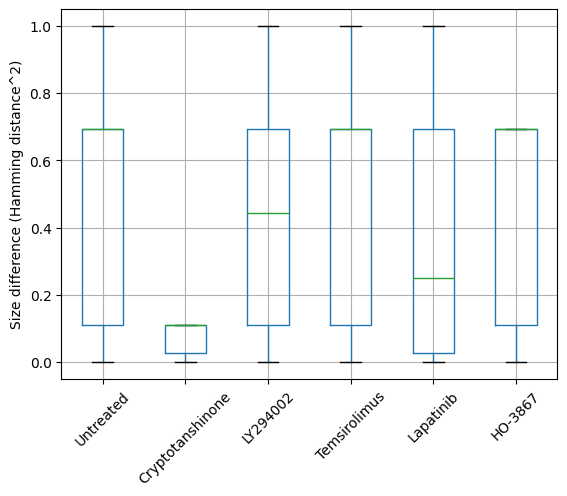

In [24]:
size_difference_single_drug = pd.DataFrame(size_difference_single_drug)
ax = size_difference_single_drug.boxplot()
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Size difference (Hamming distance^2)')


Text(0, 0.5, 'Size difference (Hamming distance^2)')

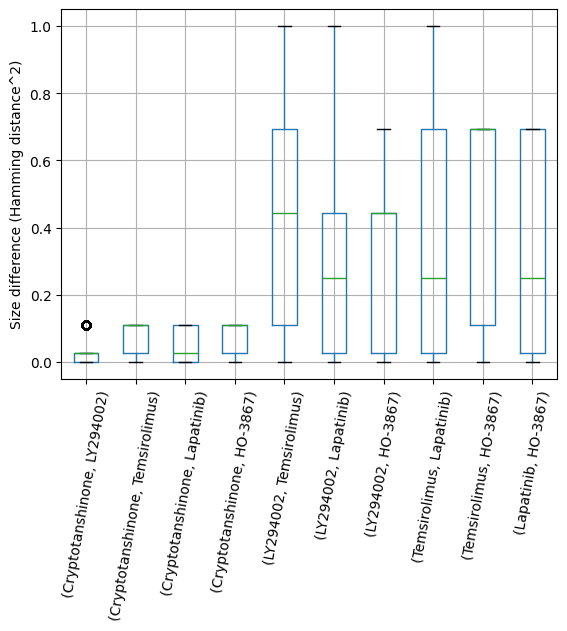

In [25]:
size_difference_double_drug = pd.DataFrame(size_difference_double_drug)
ax = size_difference_double_drug.boxplot()
ax.tick_params(axis='x', rotation=80)
ax.set_ylabel('Size difference (Hamming distance^2)')


These results are virtually identical to the results shown in Figure 5 of the paper.

Text(0, 0.5, 'Size difference (Hamming distance^2)')

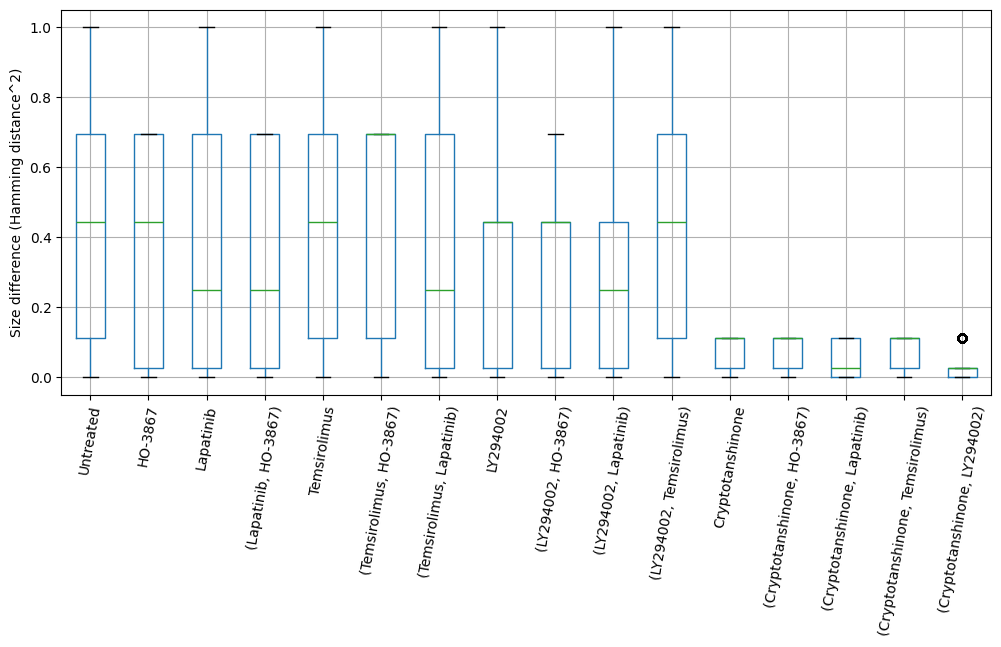

In [46]:
# combined plot
combined = pd.concat([size_differences_single_drug, size_difference_double_drug], axis=0)
# order to match paper
ordered_drugs = ['Untreated', 'HO-3867', 
    'Lapatinib', ('Lapatinib', 'HO-3867'), 
    'Temsirolimus', ('Temsirolimus', 'HO-3867'), ('Temsirolimus', 'Lapatinib'),
    'LY294002', ('LY294002', 'HO-3867'), ('LY294002', 'Lapatinib'), ('LY294002', 'Temsirolimus'),
    'Cryptotanshinone', ('Cryptotanshinone', 'HO-3867'), ('Cryptotanshinone', 'Lapatinib'), ('Cryptotanshinone', 'Temsirolimus'), ('Cryptotanshinone', 'LY294002')]
combined = combined[ordered_drugs]

fig, ax = plt.subplots(figsize=(12, 5))
ax = combined.boxplot()
ax.tick_params(axis='x', rotation=80)
ax.set_ylabel('Size difference (Hamming distance^2)')